In [19]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt

In [20]:
import os

# Correct base directory path
base_dir = os.path.join(os.getcwd(), "unzipped_dataset", "modified-dataset")

# Define paths for train, val, and test directories
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

# Print to verify
print("Train directory:", train_dir)
print("Validation directory:", val_dir)
print("Test directory:", test_dir)


Train directory: C:\Users\BHARANIDHARAN.S\imageclassifyModel\unzipped_dataset\modified-dataset\train
Validation directory: C:\Users\BHARANIDHARAN.S\imageclassifyModel\unzipped_dataset\modified-dataset\val
Test directory: C:\Users\BHARANIDHARAN.S\imageclassifyModel\unzipped_dataset\modified-dataset\test


In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set image size and batch size
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# 1. Training Data Generator (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

# 2. Validation and Test Data Generators (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Load training images
train_data = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# 4. Load validation images
val_data = val_test_datagen.flow_from_directory(
    directory=val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# 5. Load test images
test_data = val_test_datagen.flow_from_directory(
    directory=test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # So predictions match file order
)


Found 2400 images belonging to 10 classes.
Found 300 images belonging to 10 classes.
Found 300 images belonging to 10 classes.


In [22]:
model = models.Sequential()

# Add input layer explicitly first
model.add(layers.Input(shape=(150, 150, 3)))

# Then the Conv layers
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(train_data.num_classes, activation='softmax'))


In [23]:
# Compile the model before training
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [24]:
# Train the model
history = model.fit(
    train_data,
    epochs=80,
    validation_data=val_data
)


Epoch 1/80
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 410ms/step - accuracy: 0.1371 - loss: 2.3614 - val_accuracy: 0.3500 - val_loss: 1.9075
Epoch 2/80
75/75 ━━━━━━━━━━━━━━━━━━━━ 30s 400ms/step - accuracy: 0.2933 - loss: 1.9734 - val_accuracy: 0.5133 - val_loss: 1.5089
Epoch 3/80
75/75 ━━━━━━━━━━━━━━━━━━━━ 30s 399ms/step - accuracy: 0.4191 - loss: 1.6948 - val_accuracy: 0.5400 - val_loss: 1.3080
Epoch 4/80
75/75 ━━━━━━━━━━━━━━━━━━━━ 30s 401ms/step - accuracy: 0.4776 - loss: 1.4821 - val_accuracy: 0.5833 - val_loss: 1.2098
Epoch 5/80
75/75 ━━━━━━━━━━━━━━━━━━━━ 30s 399ms/step - accuracy: 0.5586 - loss: 1.3307 - val_accuracy: 0.6700 - val_loss: 1.0545
Epoch 6/80
75/75 ━━━━━━━━━━━━━━━━━━━━ 30s 401ms/step - accuracy: 0.5558 - loss: 1.2476 - val_accuracy: 0.6967 - val_loss: 0.9891
Epoch 7/80
75/75 ━━━━━━━━━━━━━━━━━━━━ 30s 400ms/step - accuracy: 0.6058 - loss: 1.1289 - val_accuracy: 0.6767 - val_loss: 0.9492
Epoch 8/80
75/75 ━━━━━━━━━━━━━━━━━━━━ 30s 400ms/step - accuracy: 0.6222 - loss: 1.1135 - val_accu

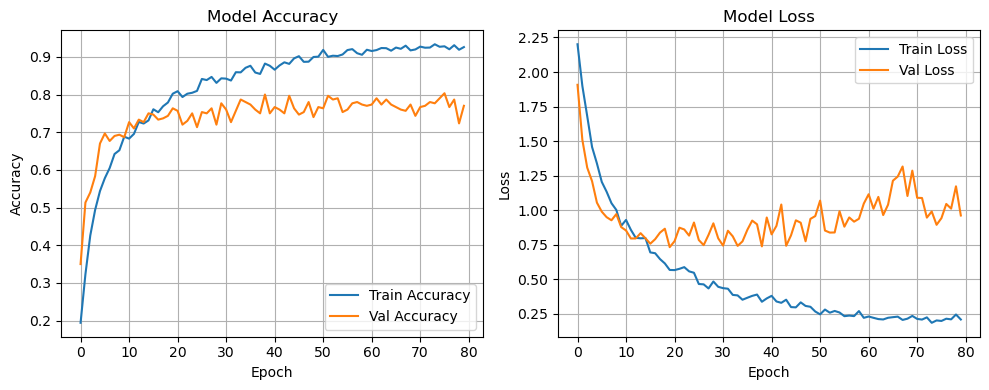

In [28]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [27]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(test_data)

print(f"\n✅ Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"✅ Test Loss: {test_loss:.4f}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.7079 - loss: 1.4665

✅ Test Accuracy: 72.00%
✅ Test Loss: 1.4272


✅ Found: C:/Users/BHARANIDHARAN.S/imageclassifyModel/unzipped_dataset/modified-dataset\train
✅ Found: C:/Users/BHARANIDHARAN.S/imageclassifyModel/unzipped_dataset/modified-dataset\val
✅ Found: C:/Users/BHARANIDHARAN.S/imageclassifyModel/unzipped_dataset/modified-dataset\test
Found 2400 images belonging to 10 classes.
Found 300 images belonging to 10 classes.
Found 300 images belonging to 10 classes.
🔧 Training with frozen base...
Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 69s 804ms/step - accuracy: 0.4779 - loss: 1.6065 - val_accuracy: 0.9367 - val_loss: 0.2693
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 58s 767ms/step - accuracy: 0.8474 - loss: 0.5036 - val_accuracy: 0.9467 - val_loss: 0.1951
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 58s 771ms/step - accuracy: 0.8936 - loss: 0.3398 - val_accuracy: 0.9333 - val_loss: 0.1895
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 58s 765ms/step - accuracy: 0.9000 - loss: 0.3065 - val_accuracy: 0.9400 - val_loss: 0.1733
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 57s 763ms/st

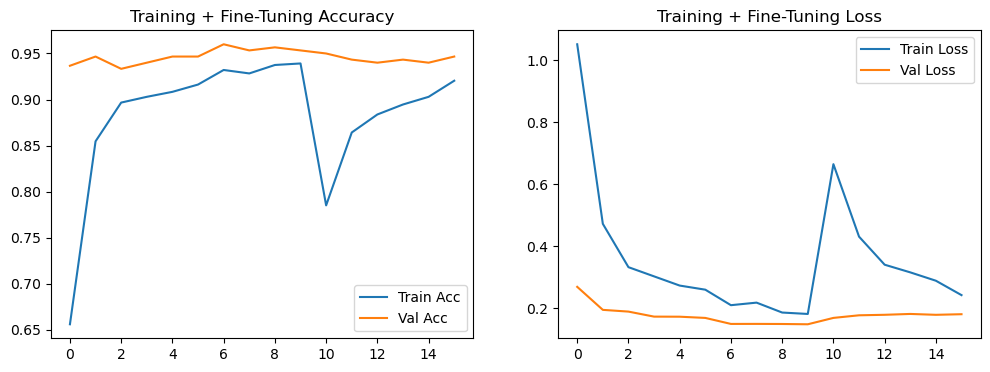

In [30]:
# ✅ Step 1: Import Libraries
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ✅ Step 2: Set Correct Dataset Paths
base_dir = r"C:/Users/BHARANIDHARAN.S/imageclassifyModel/unzipped_dataset/modified-dataset"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# Optional check: ensure all folders exist
for folder in [train_dir, val_dir, test_dir]:
    if not os.path.exists(folder):
        print(f"❌ Missing: {folder}")
    else:
        print(f"✅ Found: {folder}")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ✅ Step 3: Create Data Generators
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, zoom_range=0.2, horizontal_flip=True)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
val_data = val_test_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
test_data = val_test_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# ✅ Step 4: Load Pretrained MobileNetV2
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze all layers initially

# ✅ Step 5: Build Final Model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

# ✅ Step 6: Compile and Train (Frozen base)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("🔧 Training with frozen base...")
history = model.fit(train_data, epochs=10, validation_data=val_data)

# ✅ Step 7: Fine-Tune (Unfreeze last 30 layers)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("🚀 Fine-tuning last 30 layers...")
history_finetune = model.fit(train_data, validation_data=val_data, epochs=20, callbacks=[early_stop])

# ✅ Step 8: Evaluate on Test Set
test_loss, test_accuracy = model.evaluate(test_data)
print(f"\n✅ Test Accuracy after fine-tuning: {test_accuracy * 100:.2f}%")
print(f"✅ Test Loss after fine-tuning: {test_loss:.4f}")

# ✅ Step 9: Save Final Model
model.save("mobilenet_transfer_finetuned.keras")
print("💾 Model saved as 'mobilenet_transfer_finetuned.keras'")

# ✅ Step 10: Plot Training + Fine-Tuning Curves
def plot_training(history1, history2):
    acc = history1.history['accuracy'] + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss = history1.history['loss'] + history2.history['loss']
    val_loss = history1.history['val_loss'] + history2.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    plt.legend(loc='lower right')
    plt.title('Training + Fine-Tuning Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend(loc='upper right')
    plt.title('Training + Fine-Tuning Loss')
    plt.show()

plot_training(history, history_finetune)


<>:35: SyntaxWarning: invalid escape sequence '\p'
<>:35: SyntaxWarning: invalid escape sequence '\p'
C:\Users\BHARANIDHARAN.S\AppData\Local\Temp\ipykernel_14316\3203376289.py:35: SyntaxWarning: invalid escape sequence '\p'
  image_path = "C:\python\heart\mobile.jpg"


✅ Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


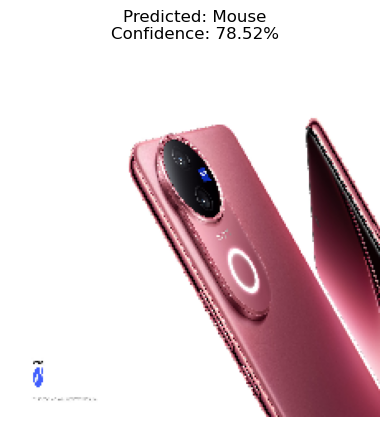

In [36]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os

# ✅ 1. Load the trained model
model = tf.keras.models.load_model("mobilenet_transfer_finetuned.keras")
print("✅ Model loaded successfully!")

# ✅ 2. Function to predict an image


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
C:\Users\BHARANIDHARAN.S\AppData\Local\Temp\ipykernel_14316\2939494720.py:24: SyntaxWarning: invalid escape sequence '\p'
  image_path = "C:\python\heart\keyboard.webp"


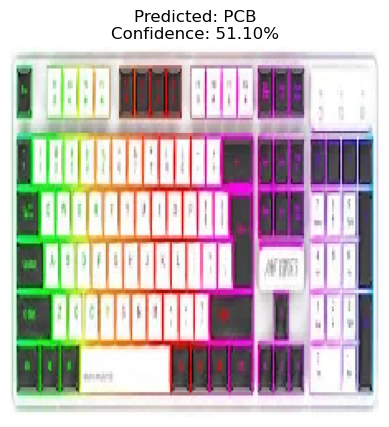

In [37]:
def predict_image(image_path):
    # Load and preprocess the image
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions)

    # Get class labels from your train_data
    class_labels = list(train_data.class_indices.keys())
    predicted_label = class_labels[predicted_class]
    confidence = predictions[0][predicted_class] * 100

    # Show image and prediction
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_label}\nConfidence: {confidence:.2f}%")
    plt.show()

# ✅ 3. Provide your image path here
# Example: if your image is in same folder as notebook, just put the filename
image_path = "C:\python\heart\keyboard.webp"
# 👈 change this to your image file
predict_image(image_path)


In [38]:
model.save("mobilenet_transfer_finetuned.keras")
print("💾 Model saved as 'mobilenet_transfer_finetuned.keras'")


💾 Model saved as 'mobilenet_transfer_finetuned.keras'
